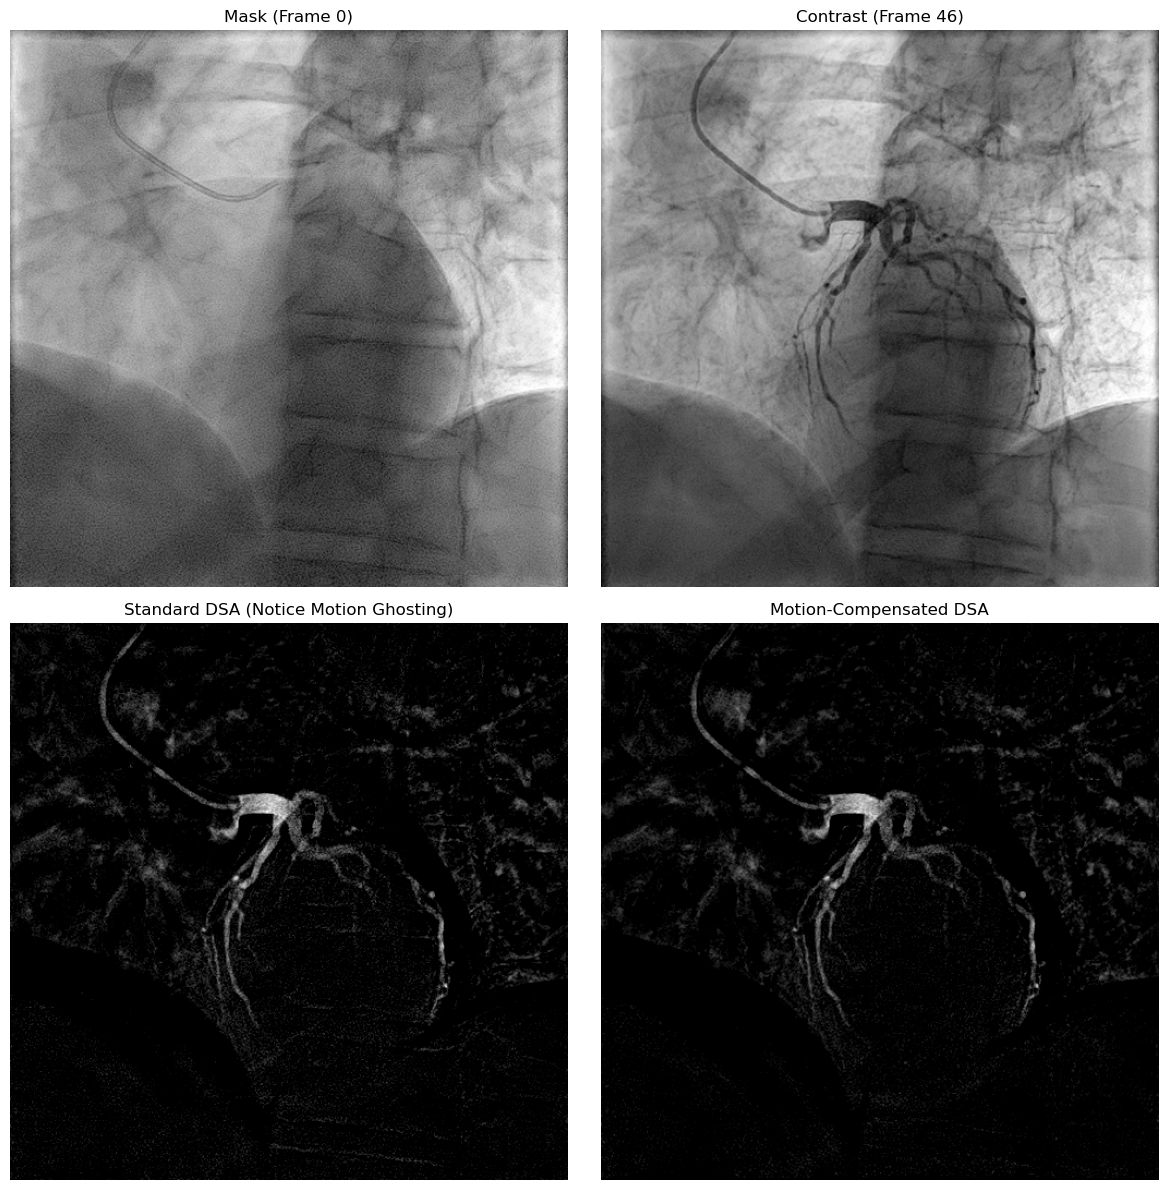

Saving individual frames...
Individual images saved successfully!


In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def motion_compensated_dsa(video_path, contrast_frame_index=15):
    # 1. Read the frames
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert to grayscale and float32 to prevent clipping during math
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        frames.append(gray)
    cap.release()

    # 2. Define Mask and Contrast frames
    mask_frame = frames[0]  # Frame 0 as requested
    
    # Ensure the contrast index isn't out of bounds
    contrast_frame_index = min(contrast_frame_index, len(frames) - 1)
    contrast_frame = frames[contrast_frame_index]

    # 3. Standard DSA (Uncompensated) for comparison
    dsa_standard = mask_frame - contrast_frame
    dsa_standard = np.clip(dsa_standard, 0, 255)

    # --- NEW STEP: Pre-process with CLAHE to help the algorithm track features ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    # Convert frames to uint8 specifically for CLAHE processing
    contrast_uint8 = cv2.normalize(contrast_frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    mask_uint8 = cv2.normalize(mask_frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    contrast_eq = clahe.apply(contrast_uint8)
    mask_eq = clahe.apply(mask_uint8)

    # --- UPDATED STEP 4: Compute Dense Optical Flow with Tuned Parameters ---
    flow = cv2.calcOpticalFlowFarneback(
        prev=contrast_eq,  # Use the enhanced images to calculate the flow...
        next=mask_eq, 
        flow=None, 
        pyr_scale=0.5, 
        levels=10,          # INCREASED: Better for large displacements
        winsize=100,        # INCREASED: Captures bulk tissue/breathing motion better
        iterations=1000,      # INCREASED: Higher precision
        poly_n=7,          # INCREASED: More robust to X-ray noise
        poly_sigma=1.5,    # Matched to poly_n=7
        flags=0
    )
    
    # NOTE: You still apply the resulting 'flow' to warp the ORIGINAL 'mask_frame' 
    # as you did in Step 5, not the CLAHE image.

    # 5. Warp the Mask using the computed flow
    h, w = mask_frame.shape
    # Create a grid of x, y coordinates
    y, x = np.mgrid[0:h, 0:w].astype(np.float32)
    
    # Add the optical flow vectors to the coordinate grid
    new_x = x + flow[..., 0]
    new_y = y + flow[..., 1]
    
    # Remap (warp) the mask frame
    warped_mask = cv2.remap(mask_frame, new_x, new_y, cv2.INTER_LINEAR)

    # 6. Motion-Compensated DSA
    dsa_compensated = warped_mask - contrast_frame
    dsa_compensated = np.clip(dsa_compensated, 0, 255)

    return mask_frame, contrast_frame, dsa_standard, dsa_compensated

# ==========================================
# Execution and Visualization
# ==========================================
if __name__ == "__main__":
    # Replace the placeholder line with your actual filename
    video_path = "10_1.3.46.670589.29.1877192777354251333378695744484882_pixel_array.gif" 
    
    # Pick a frame where contrast is highly visible (adjust index as needed)
    contrast_idx = 46 
    
    mask, contrast, dsa_raw, dsa_comp = motion_compensated_dsa(video_path, contrast_idx)

    # Plot the results side-by-side
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    axes[0, 0].imshow(mask, cmap='gray')
    axes[0, 0].set_title('Mask (Frame 0)')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(contrast, cmap='gray')
    axes[0, 1].set_title(f'Contrast (Frame {contrast_idx})')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(dsa_raw, cmap='gray')
    axes[1, 0].set_title('Standard DSA (Notice Motion Ghosting)')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(dsa_comp, cmap='gray')
    axes[1, 1].set_title('Motion-Compensated DSA')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()
    
    print("Saving individual frames...")
    
    # Convert to 8-bit integers for safe saving
    mask_save = mask.astype(np.uint8)
    contrast_save = contrast.astype(np.uint8)
    dsa_raw_save = dsa_raw.astype(np.uint8)
    dsa_comp_save = dsa_comp.astype(np.uint8)

    # Write the files to your folder
    cv2.imwrite("01_mask_frame.png", mask_save)
    cv2.imwrite("02_contrast_frame.png", contrast_save)
    cv2.imwrite("03_standard_dsa.png", dsa_raw_save)
    cv2.imwrite("04_motion_compensated_dsa.png", dsa_comp_save)
    
    print("Individual images saved successfully!")

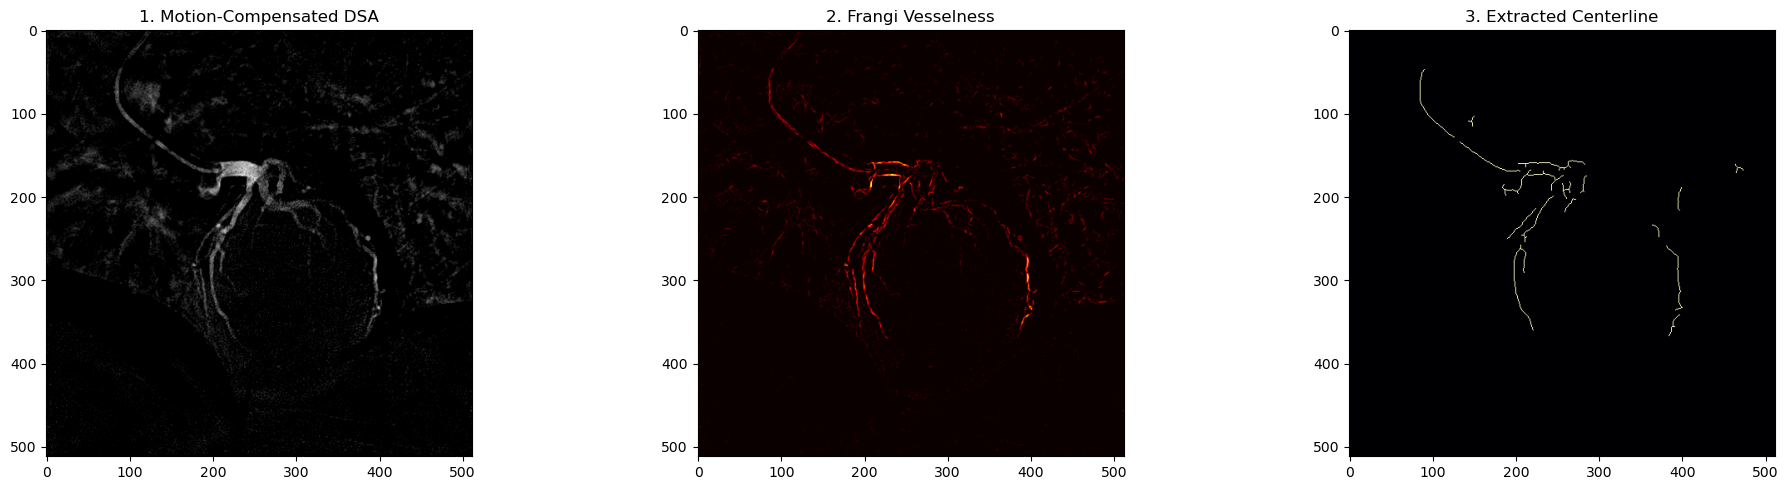

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.morphology import skeletonize

# 1. Load your processed DSA Image
# Replace this with the exact filename you used when saving the motion-compensated DSA
dsa_file = '04_motion_compensated_dsa.png' 

# Read directly in grayscale
sample_img = cv2.imread(dsa_file, cv2.IMREAD_GRAYSCALE)

if sample_img is None:
    raise FileNotFoundError(f"Could not load {dsa_file}. Make sure the image is in the same directory.")

# Convert to float for accurate Frangi processing
sample_img = sample_img.astype(np.float64)

# 2. Your Vessel Segmentation Pipeline Class (Adjusted parameters)
class VesselSegmentationPipeline:
    def __init__(self, frangi_scales=(1.0, 70.0), frangi_step=1.0, 
                 morphology_kernel_size=3, vessel_threshold=0.05, 
                 min_vessel_area=10):
        
        self.frangi_scales = np.arange(frangi_scales[0], frangi_scales[1] + frangi_step, frangi_step)
        
        # CHANGED: Using a CROSS kernel. It preserves thin diagonal lines better than ELLIPSE.
        self.kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (morphology_kernel_size, morphology_kernel_size))
        
        self.vessel_threshold = vessel_threshold
        self.min_vessel_area = min_vessel_area # New parameter for area filtering
        
    def segment(self, image):
        # 1. Frangi filter
        vesselness = frangi(image, sigmas=self.frangi_scales, black_ridges=False)
        vesselness = (vesselness - np.min(vesselness)) / (np.max(vesselness) - np.min(vesselness) + 1e-8)
        
        # 2. Binary Threshold
        binary = (vesselness > self.vessel_threshold).astype(np.uint8) * 255
        
        # 3. Morphological cleanup (Opening removes noise, Closing fills gaps)
        opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, self.kernel)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, self.kernel)
        
        # 4. CHANGED: Area-based Connected Components Filtering
        # This gives us the size (area) of every distinct white object in the image
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)
        
        # Create a blank black image to draw our filtered vessels onto
        vessel_mask = np.zeros_like(closed)
        
        # Loop through all detected objects (skip label 0, which is the black background)
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            # If the object is larger than our minimum area, keep it!
            if area >= self.min_vessel_area:
                vessel_mask[labels == i] = 255
                
        # 5. Skeletonize the filtered mask
        skeleton = skeletonize(vessel_mask > 0).astype(np.uint8) * 255
        
        return vessel_mask, skeleton, vesselness

        
# 3. Initialize and Run Pipeline
# Note: A threshold of 0.06 might be too low or too high depending on the DSA contrast. 
# You may need to tweak this between 0.01 and 0.15.
pipeline = VesselSegmentationPipeline(vessel_threshold=0.01, min_vessel_area=80)

mask, skeleton, vesselness = pipeline.segment(sample_img)

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].imshow(sample_img, cmap='gray'); axes[0].set_title('1. Motion-Compensated DSA')
axes[1].imshow(vesselness, cmap='hot'); axes[1].set_title('2. Frangi Vesselness')
axes[2].imshow(skeleton, cmap='magma'); axes[2].set_title('3. Extracted Centerline')
plt.tight_layout()
plt.show()

# Note: The Dice Score sensitivity analysis is commented out 
# because it requires a hand-drawn 'Ground Truth' mask to compare against.